In [ ]:
!pip install cmu-multimodal-sdk

In [ ]:
!pip install huggingface_hub

In [ ]:
!pip install transformers

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error
from transformers import AutoTokenizer, AutoModelForMaskedLM
from transformers import BertTokenizer, BertModel
from pathlib import Path
import logging
import math
import pickle
from sklearn.metrics import mean_absolute_error, accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn.functional as F
import seaborn as sns
import time
from mmsdk import mmdatasdk as md
import sys
from prettytable import PrettyTable
import os
from huggingface_hub import login

In [ ]:
!huggingface-cli login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    A token is already saved on your machine. Run `huggingface-cli whoami` to get more information or `huggingface-cli logout` if you want to log out.
    Setting a new token will erase the existing one.
    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) Y
Token is valid (permission: write

In [ ]:
path = kagglehub.dataset_download("samarwarsi/cmu-mosei")
print('Data source import complete.')

Data source import complete.


In [ ]:
print(path)

/kaggle/input/cmu-mosei


In [ ]:
RAW_DATA_DIR = "/kaggle/input/cmu-mosei/CMU-MOSEI"
PROCESSED_DATA_DIR = "/content/processed_data"
DATASET_NAME = "CMU_MOSEI"
TEXT_MAX_LENGTH = 128
TEXT_EMBEDDING_DIM = 768
AUDIO_FEATURE_SIZE = 40
VISUAL_FEATURE_SIZE = 35
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5

In [ ]:
torch.manual_seed(SEED)
np.random.seed(SEED)

In [ ]:
class MOSEIDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data["labels"])

    def __getitem__(self, idx):
        return {
            "acoustic": torch.tensor(self.data["acoustic"][idx], dtype=torch.float32),
            "visual": torch.tensor(self.data["visual"][idx], dtype=torch.float32),
            "language": torch.tensor(self.data["language"][idx], dtype = torch.float32),
            "label": torch.tensor(self.data["labels"][idx], dtype=torch.float32)
        }


In [ ]:
class MOSEIPreprocessor:
    def __init__(self, raw_data_dir, processed_data_dir):
        self.raw_data_dir = Path(raw_data_dir)
        self.processed_data_dir = Path(processed_data_dir)
        self.processed_data_dir.mkdir(exist_ok=True, parents=True)

        self.tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
        self.bert_model = BertModel.from_pretrained("bert-base-uncased")
        self.bert_model.eval()
        self.device = DEVICE
        self.bert_model.to(self.device)
        print(f"Using device: {self.device}")

        self.data = {
           "train": {"language": [], "acoustic": [], "visual": [], "labels": []},
            "val": {"language": [], "acoustic": [], "visual": [], "labels": []},
            "test": {"language": [], "acoustic": [], "visual": [],  "labels": []}
        }

        self.metadata = {
            "text_dim": TEXT_EMBEDDING_DIM ,
            "audio_dim": AUDIO_FEATURE_SIZE,
            "visual_dim": VISUAL_FEATURE_SIZE,
            "num_classes": 1,
            "train_samples": 0,
            "val_samples": 0,
            "test_samples": 0
        }

    def load_aligned_data(self):
        print("Loading aligned data...")
        try:
            dataset = {
                "language": str(self.raw_data_dir /"languages"/ "CMU_MOSEI_TimestampedWords.csd"),
                "acoustic": str(self.raw_data_dir /"acoustics"/ "CMU_MOSEI_COVAREP.csd"),
                "visual": str(self.raw_data_dir /"visuals"/ "CMU_MOSEI_VisualOpenFace2.csd"),
                "labels": str(self.raw_data_dir /"labels"/ "CMU_MOSEI_Labels.csd")
            }
            for key, path in dataset.items():
                if not os.path.exists(path):
                    print(f"Error: File {path} does not exist")
                    return None
            mosei_dataset = md.mmdataset(dataset)
            print(f"Loaded dataset with {len(mosei_dataset['labels'].keys())} segments")
            return mosei_dataset
        except Exception as e:
            print(f"Error loading aligned data: {e}")
            return None

    def extract_text_features(self, text):
        try:
            inputs = self.tokenizer(
                text,
                padding="max_length",
                truncation=True,
                max_length=TEXT_MAX_LENGTH,
                return_tensors="pt"
            )
            inputs = {key: val.to(self.device) for key, val in inputs.items()}
            with torch.no_grad():
                # Explicitly move the model to the device before the forward pass
                self.bert_model.to(self.device)
                outputs = self.bert_model(**inputs)
                embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            return embeddings[0]

        except Exception as e:
            logger.error(f"Error extracting text features: {e}")
            return np.zeros(TEXT_EMBEDDING_DIM)

    def extract_audio_features(self, audio_features):
        if len(audio_features.shape) > 1 and audio_features.shape[0] > 0:
            selected_features = np.mean(audio_features, axis=0)
            if np.any(np.isnan(selected_features)):
                selected_features = np.nan_to_num(selected_features, nan=0.0)
            if len(selected_features) > AUDIO_FEATURE_SIZE:
                selected_features = selected_features[:AUDIO_FEATURE_SIZE]
            elif len(selected_features) < AUDIO_FEATURE_SIZE:
                selected_features = np.pad(selected_features, (0, AUDIO_FEATURE_SIZE - len(selected_features)))
            return selected_features
        return np.zeros(AUDIO_FEATURE_SIZE)

    def extract_visual_features(self, visual_features):
        if len(visual_features.shape) > 1 and visual_features.shape[0] > 0:
            selected_features = np.mean(visual_features, axis=0)
            if np.any(np.isnan(selected_features)):
                selected_features = np.nan_to_num(selected_features, nan=0.0)
            if len(selected_features) > VISUAL_FEATURE_SIZE:
                selected_features = selected_features[:VISUAL_FEATURE_SIZE]
            elif len(selected_features) < VISUAL_FEATURE_SIZE:
                selected_features = np.pad(selected_features, (0, VISUAL_FEATURE_SIZE - len(selected_features)))
            return selected_features
        return np.zeros(VISUAL_FEATURE_SIZE)

    def process_dataset(self):
        print("Preprocessing dataset...")
        dataset = self.load_aligned_data()
        if dataset is None:
            print("Cannot loading dataset")
            return False

        segment_ids = list(dataset["labels"].keys())
        print(f"Find {len(segment_ids)} segment in dataset")

        train_ids, test_ids = train_test_split(segment_ids, test_size=0.2, random_state=SEED)
        train_ids, val_ids = train_test_split(train_ids, test_size=0.1, random_state=SEED)

        splits = {"train": train_ids, "val": val_ids, "test": test_ids}

        for split_name, split_ids in splits.items():
            print(f"Processing file {split_name} with {len(split_ids)} segment")
            for segment_id in tqdm(split_ids, desc=f"Preprocessing {split_name}"):
                try:
                    text_features = dataset["language"][segment_id]["features"]
                    audio_features = dataset["acoustic"][segment_id]["features"]
                    visual_features = dataset["visual"][segment_id]["features"]
                    label = dataset["labels"][segment_id]["features"]

                    text_str = " ".join([word[0].decode('utf-8') if isinstance(word[0], bytes) else str(word[0]) for word in text_features])

                    text_embedding = self.extract_text_features(text_str)
                    audio_embedding = self.extract_audio_features(audio_features)
                    visual_embedding = self.extract_visual_features(visual_features)
                    sentiment_score = np.mean(label)

                    if np.isnan(sentiment_score):
                        continue
                    self.data[split_name]["language"].append(text_embedding)
                    self.data[split_name]["acoustic"].append(audio_embedding)
                    self.data[split_name]["visual"].append(visual_embedding)
                    self.data[split_name]["labels"].append(sentiment_score)
                except Exception as e:
                    print(f"Error while processing segment {segment_id}: {e}")
                    continue

            self.metadata[f"{split_name}_samples"] = len(self.data[split_name]["labels"])
            print(f"Set {split_name} có {self.metadata[f'{split_name}_samples']} mẫu")
        print(f"Các khóa trong self.data[{split_name}]: {list(self.data[split_name].keys())}")
        print("Dataset processing complete")
        return True

    def save_processed_data(self):
        print("Saving processed data...")
        for split_name in ["train", "val", "test"]:
            for modality in ["language", "acoustic", "visual", "labels"]:
                self.data[split_name][modality] = np.array(self.data[split_name][modality])
                if np.any(np.isnan(self.data[split_name][modality])):
                    self.data[split_name][modality] = np.nan_to_num(self.data[split_name][modality], nan=0.0)

            split_file = self.processed_data_dir / f"{split_name}_data.pkl"
            with open(split_file, "wb") as f:
                pickle.dump(self.data[split_name], f)
            print(f"Saved data {split_name} vào {split_file}")

        metadata_file = self.processed_data_dir / "metadata.pkl"
        with open(metadata_file, "wb") as f:
            pickle.dump(self.metadata, f)
        print(f"Saved metadata to {metadata_file}")

In [ ]:
preprocessor = MOSEIPreprocessor(RAW_DATA_DIR, PROCESSED_DATA_DIR)
print("Preprocessing dataset...")
if not preprocessor.process_dataset():
    print("Can not process dataset")
    # return

print("Saving processed data...")
preprocessor.save_processed_data()

train_dataset = MOSEIDataset(preprocessor.data["train"])
val_dataset = MOSEIDataset(preprocessor.data["val"])
test_dataset = MOSEIDataset(preprocessor.data["test"])

Using device: cuda
Preprocessing dataset...
Preprocessing dataset...
Loading aligned data...
<Success>: Computational sequence read from file /kaggle/input/cmu-mosei/CMU-MOSEI/languages/CMU_MOSEI_TimestampedWords.csd ...
<Status>: Checking the integrity of the data in <b'"words"'> computational sequence ...



100%|█████████▉| 3832/3837 [00:07<00:00, 799.45 Computational Sequence Entries/s]
                                                                                 

<Success>: <b'"words"'> computational sequence data in correct format.
<Status>: Checking the integrity of the metadata in <b'"words"'> computational sequence ...
<Success>: <b'"words"'> computational sequence metadata in correct format
<Success>: Computational sequence read from file /kaggle/input/cmu-mosei/CMU-MOSEI/acoustics/CMU_MOSEI_COVAREP.csd ...
<Status>: Checking the integrity of the data in <b'"COVAREP"'> computational sequence ...



 99%|█████████▉| 3792/3836 [00:10<00:00, 439.33 Computational Sequence Entries/s]
                                                                                 

<Success>: <b'"COVAREP"'> computational sequence data in correct format.
<Status>: Checking the integrity of the metadata in <b'"COVAREP"'> computational sequence ...
<Success>: <b'"COVAREP"'> computational sequence metadata in correct format
<Success>: Computational sequence read from file /kaggle/input/cmu-mosei/CMU-MOSEI/visuals/CMU_MOSEI_VisualOpenFace2.csd ...
<Status>: Checking the integrity of the data in <b'"OpenFace_2"'> computational sequence ...


...

Set val có 264 mẫu
Processing file test with 659 segment



Preprocessing test:  82%|████████▏ | 543/659 [01:49<00:16,  7.17it/s]

Error while processing segment PEBwwe0PLZ8: 'PEBwwe0PLZ8'



Preprocessing test: 100%|██████████| 659/659 [02:13<00:00,  4.95it/s]


Set test có 658 mẫu
Các khóa trong self.data[test]: ['language', 'acoustic', 'visual', 'labels']
Dataset processing complete
Saving processed data...
Saving processed data...
Saved data train vào /content/processed_data/train_data.pkl
Saved data val vào /content/processed_data/val_data.pkl
Saved data test vào /content/processed_data/test_data.pkl
Saved metadata to /content/processed_data/metadata.pkl


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
print(f"Created DataLoader: Train={len(train_loader.dataset)}, Val={len(val_loader.dataset)}, Test={len(test_loader.dataset)}")

Created DataLoader: Train=2370, Val=264, Test=658


In [ ]:
for batch in test_loader:
    print("Batch type:", type(batch))
    print("Batch content:", batch)
    break

Batch type: <class 'dict'>
Batch content: {'acoustic': tensor([[1.1840e+02, 5.9162e-01, 6.2803e-02,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [1.9144e+02, 7.2866e-01, 8.9589e-02,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [1.8668e+02, 5.8062e-01, 8.1468e-02,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        ...,
        [1.9407e+02, 6.7117e-01, 1.0655e-01,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [2.2119e+02, 7.2512e-01, 1.0256e-01,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [1.9767e+02, 6.2978e-01, 8.0046e-02,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00]]), 'visual': tensor([[  0.0000,  17.0167,   0.9800,  ..., 354.8990, 356.0960, 357.2409],
        [  0.0000,  38.5667,   0.9640,  ..., 237.2046, 238.4691, 239.7208],
        [  0.0000,  28.8000,   0.9663,  ..., 612.7575, 614.7434, 616.7589],
        ...,
        [  0.0000,  29.2167,   0.9800,  ..., 252.3540, 253.9496, 255.4945],
        [  0.0000,  5

Batch type: <class 'dict'>
Batch keys: ['acoustic', 'visual', 'language', 'label']


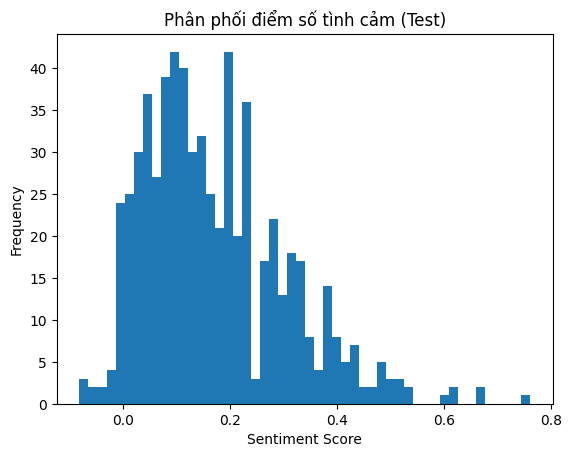

In [ ]:
if 'test_loader' not in globals():
    raise ValueError("test_loader is not defined. Ensure DataLoader is initialized.")

for batch in test_loader:
    print("Batch type:", type(batch))
    if isinstance(batch, dict):
        print("Batch keys:", list(batch.keys()))
    else:
        print("Batch length:", len(batch))
        print("Batch content:", [b.shape if isinstance(b, torch.Tensor) else type(b) for b in batch])
    break

targets = []
try:
    for batch in test_loader:
        if isinstance(batch, dict):
            targets.extend(batch["label"].numpy())
        else:
            # Multimodal: (text, audio, video, target); Unimodal: (input_data, target)
            target_idx = -1 if len(batch) > 2 else 1
            targets.extend(batch[target_idx].numpy())
except Exception as e:
    print("Error extracting targets:", e)
    raise

# Plot distribution
plt.hist(targets, bins=50)
plt.title("Phân phối điểm số tình cảm (Test)")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()

In [ ]:
class CrossAttention(nn.Module):
    def __init__(self, query_dim, key_dim, value_dim, hidden_dim, num_heads=8, dropout_rate=0.1):
        super(CrossAttention, self).__init__()

        self.num_heads = num_heads
        self.hidden_dim = hidden_dim
        self.head_dim = hidden_dim // num_heads
        assert self.head_dim * num_heads == hidden_dim, "hidden_dim must be divisible by num_heads"

        # Linear layers to project query, key, and value to hidden dimensions
        self.query_proj = nn.Linear(query_dim, hidden_dim)
        self.key_proj = nn.Linear(key_dim, hidden_dim)
        self.value_proj = nn.Linear(value_dim, hidden_dim)

        # Output projection
        self.output_proj = nn.Linear(hidden_dim, hidden_dim)

        # Dropout for regularization
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, query, key, value):
        batch_size = query.size(0)

        # Project query, key, value
        query = self.query_proj(query).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        key = self.key_proj(key).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        value = self.value_proj(value).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)

        # Calculate attention scores
        attention_scores = torch.matmul(query, key.transpose(-2, -1))
        attention_scores = attention_scores / math.sqrt(self.head_dim)

        # Apply softmax to get attention weights
        attention_weights = F.softmax(attention_scores, dim=-1)
        attention_weights = self.dropout(attention_weights)

        # Apply attention weights to values
        attended_values = torch.matmul(attention_weights, value)

        # Reshape and project output
        attended_values = attended_values.transpose(1, 2).contiguous().view(batch_size, -1, self.hidden_dim)
        output = self.output_proj(attended_values)

        # Remove sequence dimension if only one token
        if output.size(1) == 1:
            output = output.squeeze(1)

        return output



In [ ]:
class MultimodalCrossAttention(nn.Module):
    def __init__(
        self,
        text_dim,
        audio_dim,
        visual_dim,
        hidden_dim=256,
        num_heads=8,
        dropout_rate=0.1
    ):
        super(MultimodalCrossAttention, self).__init__()

        # Project input modalities to common hidden dimension
        self.text_proj = nn.Linear(text_dim, hidden_dim)
        # self.audio_proj = nn.Linear(audio_dim, hidden_dim)
        self.visual_proj = nn.Linear(visual_dim, hidden_dim)

        # Cross-attention modules
        # Text as query, attend to audio and visual
        # self.text_audio_attn = CrossAttention(
        #     hidden_dim, hidden_dim, hidden_dim, hidden_dim, num_heads, dropout_rate
        # )
        self.text_visual_attn = CrossAttention(
            hidden_dim, hidden_dim, hidden_dim, hidden_dim, num_heads, dropout_rate
        )

        # Audio as query, attend to text and visual
        # self.audio_text_attn = CrossAttention(
        #     hidden_dim, hidden_dim, hidden_dim, hidden_dim, num_heads, dropout_rate
        # )
        # self.audio_visual_attn = CrossAttention(
        #     hidden_dim, hidden_dim, hidden_dim, hidden_dim, num_heads, dropout_rate
        # )

        # Visual as query, attend to text and audio
        self.visual_text_attn = CrossAttention(
            hidden_dim, hidden_dim, hidden_dim, hidden_dim, num_heads, dropout_rate
        )
        # self.visual_audio_attn = CrossAttention(
        #     hidden_dim, hidden_dim, hidden_dim, hidden_dim, num_heads, dropout_rate
        # )

        # Final fusion layer
        self.fusion_layer = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim * 2),
            nn.LayerNorm(hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )

        # Output projection for sentiment prediction
        self.output_proj = nn.Linear(hidden_dim, 1)

    def forward(self, text_features, visual_features):
        batch_size = text_features.size(0)

        # Project features to the hidden dimension
        text_proj = self.text_proj(text_features)
        # audio_proj = self.audio_proj(audio_features)
        visual_proj = self.visual_proj(visual_features)

        # Add sequence dimension for attention if needed (e.g., [B, D] -> [B, 1, D])
        if len(text_proj.shape) == 2:
            text_proj = text_proj.unsqueeze(1)
            # audio_proj = audio_proj.unsqueeze(1)
            visual_proj = visual_proj.unsqueeze(1)

        # Cross-attention: text attending to other modalities
        # text_audio_attn = self.text_audio_attn(text_proj, audio_proj, audio_proj)
        text_visual_attn = self.text_visual_attn(text_proj, visual_proj, visual_proj)
        text_context = text_proj + text_visual_attn

        # Cross-attention: audio attending to other modalities
        # audio_text_attn = self.audio_text_attn(audio_proj, text_proj, text_proj)
        # audio_visual_attn = self.audio_visual_attn(audio_proj, visual_proj, visual_proj)
        # audio_context = audio_proj + audio_text_attn + audio_visual_attn

        # Cross-attention: visual attending to other modalities
        visual_text_attn = self.visual_text_attn(visual_proj, text_proj, text_proj)
        # visual_audio_attn = self.visual_audio_attn(visual_proj, audio_proj, audio_proj)
        visual_context = visual_proj + visual_text_attn
        # Remove sequence dimension ([B, 1, D] -> [B, D])
        if len(text_proj.shape) == 3:
            text_proj = text_proj.squeeze(1)
            # audio_proj = audio_proj.squeeze(1)
            visual_proj = visual_proj.squeeze(1)

        # Concatenate fused features from all modalities
        concat_features = torch.cat([text_features,  visual_features], dim=1)

        # Apply fusion layer
        fused_features = self.fusion_layer(concat_features)

        # Predict sentiment
        sentiment = self.output_proj(fused_features)

        return fused_features, sentiment

In [ ]:
def compute_regression_accuracy(preds, labels, tolerance=0.1):
    correct = np.sum(np.abs(preds - labels) <= tolerance)
    return correct / len(labels)


In [ ]:
def evaluate_metrics(preds, labels):
    mae = mean_absolute_error(labels, preds)
    mse = mean_squared_error(labels, preds)
    if np.std(preds) == 0 or np.std(labels) == 0:
        corr = 0
    else:
        corr = np.corrcoef(preds, labels)[0, 1]
    return {"mae": mae, "mse": mse, "corr": corr}


In [ ]:
def compute_accuracy(preds, labels, tolerance=0.1):
    preds = np.array(preds)
    labels = np.array(labels)
    return np.mean(np.abs(preds - labels) <= tolerance)

In [ ]:
class AudioSentimentModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout_rate=0.3):
        super(AudioSentimentModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.batch_norm1 = nn.BatchNorm1d(hidden_dim)

        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_dim // 2)

        self.fc3 = nn.Linear(hidden_dim // 2, 1)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = self.fc1(x)
        x = self.batch_norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.batch_norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)

        return x

In [ ]:
def accuracy_within_tolerance(preds, labels, tolerance=0.1):
    preds = np.array(preds)
    labels = np.array(labels)
    correct = np.abs(preds - labels) <= tolerance
    return np.mean(correct)


In [ ]:
def check_nan_in_loader(loader):
    total_batches = 0
    bad_batches = 0

    for batch in loader:
        total_batches += 1

        # Bỏ qua label
        inputs = {k: v for k, v in batch.items() if k != 'label'}

        # Kiểm tra từng modality
        bad_input = False
        for modality_name, modality_tensor in inputs.items():
            if torch.isnan(modality_tensor).any() or torch.isinf(modality_tensor).any():
                print(f"⚠️ Found NaN/Inf in '{modality_name}' at batch {total_batches}")
                bad_input = True
                break

        if bad_input:
            bad_batches += 1

    print(f"🧪 Total batches: {total_batches}, Batches with NaN/Inf: {bad_batches}")


In [ ]:
check_nan_in_loader(train_loader)


⚠️ Found NaN/Inf in 'acoustic' at batch 1
⚠️ Found NaN/Inf in 'acoustic' at batch 2
⚠️ Found NaN/Inf in 'acoustic' at batch 3
⚠️ Found NaN/Inf in 'acoustic' at batch 4
⚠️ Found NaN/Inf in 'acoustic' at batch 5
⚠️ Found NaN/Inf in 'acoustic' at batch 6
⚠️ Found NaN/Inf in 'acoustic' at batch 7
⚠️ Found NaN/Inf in 'acoustic' at batch 8
⚠️ Found NaN/Inf in 'acoustic' at batch 9
⚠️ Found NaN/Inf in 'acoustic' at batch 10
⚠️ Found NaN/Inf in 'acoustic' at batch 11
⚠️ Found NaN/Inf in 'acoustic' at batch 12
⚠️ Found NaN/Inf in 'acoustic' at batch 13
⚠️ Found NaN/Inf in 'acoustic' at batch 14
⚠️ Found NaN/Inf in 'acoustic' at batch 15
⚠️ Found NaN/Inf in 'acoustic' at batch 16
⚠️ Found NaN/Inf in 'acoustic' at batch 17
⚠️ Found NaN/Inf in 'acoustic' at batch 18
⚠️ Found NaN/Inf in 'acoustic' at batch 19
⚠️ Found NaN/Inf in 'acoustic' at batch 20
⚠️ Found NaN/Inf in 'acoustic' at batch 21
⚠️ Found NaN/Inf in 'acoustic' at batch 22
⚠️ Found NaN/Inf in 'acoustic' at batch 23
⚠️ Found NaN/Inf in 

In [ ]:
# Lấy một batch đầu tiên từ train_loader
first_batch = next(iter(train_loader))

# Kiểm tra các key có trong batch
print("Các keys trong batch:", first_batch.keys())

# In ra nội dung cột 'acoustic'
print("📢 Acoustic batch:")
print(first_batch['acoustic'])


Các keys trong batch: dict_keys(['acoustic', 'visual', 'language', 'label'])
📢 Acoustic batch:
tensor([[ 1.2343e+02,  4.9910e-01,  3.2825e-02,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 2.1275e+02,  6.6782e-01,  2.8013e-02,  ...,  8.3861e-04,
         -8.6652e-04, -2.7207e-03],
        [ 1.4099e+02,  6.8161e-01,  6.3804e-02,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [ 9.9328e+01,  4.7389e-01,  6.3076e-02,  ...,  6.5206e-03,
          6.6072e-03,  6.9023e-03],
        [ 9.9676e+01,  4.9613e-01,  3.3174e-02,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 1.2882e+02,  5.0321e-01,  8.0326e-02,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00]])


In [ ]:
acoustic_batch = first_batch['acoustic']
print("📌 Có NaN?", torch.isnan(acoustic_batch).any().item())
print("📌 Có Inf?", torch.isinf(acoustic_batch).any().item())


📌 Có NaN? False
📌 Có Inf? True


In [ ]:
def train_audio_model(train_loader, val_loader, input_dim, model_path='best_audio_model.pt', num_epochs=50, lr=1e-4):
    model = AudioSentimentModel(input_dim=input_dim).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss = 0.0
        all_train_preds, all_train_labels = [], []

        pbar = tqdm(train_loader, desc=f"[Epoch {epoch}] Training")

        for batch in pbar:
            if isinstance(batch, dict):
                inputs = batch['acoustic'].to(DEVICE)
                labels = batch['label'].to(DEVICE)
            else:
                inputs, labels = batch
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            # Check for NaN/Inf in input
            if torch.isnan(inputs).any() or torch.isinf(inputs).any():
                print("⚠️ Skipping batch: input contains NaN or Inf")
                continue

            optimizer.zero_grad()
            outputs = model(inputs)
            outputs = torch.nan_to_num(outputs, nan=0.0)

            loss = criterion(outputs.squeeze(), labels)
            if torch.isnan(loss):
                print(f"⚠️ Skipping batch: NaN loss at epoch {epoch}")
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()
            all_train_preds.extend(outputs.detach().squeeze().cpu().numpy())
            all_train_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        train_acc = accuracy_within_tolerance(np.array(all_train_preds), np.array(all_train_labels))
        train_accuracies.append(train_acc)

        # Validation
        model.eval()
        val_loss = 0.0
        all_val_preds, all_val_labels = [], []

        with torch.no_grad():
            for batch in val_loader:
                if isinstance(batch, dict):
                    inputs = batch['acoustic'].to(DEVICE)
                    labels = batch['label'].to(DEVICE)
                else:
                    inputs, labels = batch
                    inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

                outputs = model(inputs)
                outputs = torch.nan_to_num(outputs, nan=0.0)

                loss = criterion(outputs.squeeze(), labels)
                if torch.isnan(loss):
                    print(f"⚠️ Skipping val batch: NaN loss at epoch {epoch}")
                    continue

                val_loss += loss.item()
                all_val_preds.extend(outputs.detach().squeeze().cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        val_acc = accuracy_within_tolerance(np.array(all_val_preds), np.array(all_val_labels))
        val_accuracies.append(val_acc)

        # Save model if it's the best
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), model_path)

        # Logging
        print(f"[Epoch {epoch}] Train Loss: {avg_train_loss:.4f}, Train Accuracy (±0.1): {train_acc:.4f}")
        print(f"[Epoch {epoch}] Val Loss: {avg_val_loss:.4f}, Val Accuracy (±0.1): {val_acc:.4f}")
        print(f"[Epoch {epoch}] Sample Predictions: {np.array(all_val_preds[:5]).round(4)}")
        print(f"[Epoch {epoch}] Sample Labels     : {np.array(all_val_labels[:5]).round(4)}")

    return model, train_losses, val_losses, train_accuracies, val_accuracies


In [ ]:
model, train_losses, val_losses, train_accuracies, val_accuracies = train_audio_model(train_loader, val_loader, input_dim=AUDIO_FEATURE_SIZE)


[Epoch 1] Training:   0%|          | 0/74 [00:00<?, ?it/s]

⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skippin


[Epoch 1] Training: 100%|██████████| 74/74 [00:00<00:00, 633.80it/s]

⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skippin


/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


...


[Epoch 50] Training:  59%|█████▉    | 44/74 [00:00<00:00, 436.12it/s]

⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf


[Epoch 50] Training: 100%|██████████| 74/74 [00:00<00:00, 457.79it/s]

⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf
⚠️ Skipping batch: input contains NaN or Inf


[Epoch 50] Train Loss: 0.0000, Train Accuracy (±0.1): nan
[Epoch 50] Val Loss: 0.3662, Val Accuracy (±0.1): 0.2461
[Epoch 50] Sample Predictions: [0.     0.     0.     0.     1.4908]
[Epoch 50] Sample Labels     : [0.0741 0.2917 0.2659 0.1111 0.119 ]


In [ ]:
class TextSentimentModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, dropout_rate=0.3):
        super(TextSentimentModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, 1)

        self.dropout = nn.Dropout(dropout_rate)
        self.batch_norm1 = nn.BatchNorm1d(hidden_dim)
        self.batch_norm2 = nn.BatchNorm1d(hidden_dim // 2)

    def forward(self, x):
        x = self.fc1(x)
        x = self.batch_norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.batch_norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)
        return x

In [ ]:
# class TextSentimentModel(nn.Module):
#     def __init__(self, input_dim, hidden_dim=256, dropout_rate=0.3, return_features=False):
#         super(TextSentimentModel, self).__init__()
#         self.return_features = return_features  # Cho phép return feature nếu dùng Early Fusion

#         self.fc1 = nn.Linear(input_dim, hidden_dim)
#         self.norm1 = nn.LayerNorm(hidden_dim)  # Dùng LayerNorm thay vì BatchNorm
#         self.dropout1 = nn.Dropout(dropout_rate)

#         self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
#         self.norm2 = nn.LayerNorm(hidden_dim // 2)
#         self.dropout2 = nn.Dropout(dropout_rate)

#         self.output = nn.Linear(hidden_dim // 2, 1)

#     def forward(self, x):
#         x = self.fc1(x)
#         x = self.norm1(x)
#         x = F.gelu(x)  # GELU thường tốt hơn ReLU trong NLP
#         x = self.dropout1(x)

#         x = self.fc2(x)
#         x = self.norm2(x)
#         x = F.gelu(x)
#         x = self.dropout2(x)

#         if self.return_features:
#             return x  # Cho Early Fusion hoặc feature extraction

#         x = self.output(x)
#         return x


In [ ]:
def train_text_model(train_loader, val_loader, input_dim, model_path=None, num_epochs=50, lr=1e-4):
    model = TextSentimentModel(input_dim=input_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss = 0.0
        all_train_preds = []
        all_train_labels = []

        pbar = tqdm(train_loader, desc=f"[Epoch {epoch}] Training")
        for batch in pbar:
            if isinstance(batch, dict):
                inputs = batch["language"].to(DEVICE)
                labels = batch["label"].to(DEVICE)
            else:
                inputs, labels = batch
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs)
            outputs = outputs.squeeze()

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            all_train_preds.extend(outputs.detach().cpu().numpy())
            all_train_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        pbar.close()

        avg_train_loss = train_loss / len(train_loader)
        train_acc = compute_accuracy(all_train_preds, all_train_labels)

        model.eval()
        val_loss = 0.0
        all_val_preds = []
        all_val_labels = []

        with torch.no_grad():
            for batch in val_loader:
                if isinstance(batch, dict):
                    inputs = batch["language"].to(DEVICE)
                    labels = batch["label"].to(DEVICE)
                else:
                    inputs, labels = batch
                    inputs = inputs.to(DEVICE)
                    labels = labels.to(DEVICE)

                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                all_val_preds.extend(outputs.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_acc = compute_accuracy(all_val_preds, all_val_labels)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(f"[Epoch {epoch}] Train Loss: {avg_train_loss:.4f}, Train Accuracy (±0.1): {train_acc:.4f}")
        print(f"[Epoch {epoch}] Val Loss: {avg_val_loss:.4f}, Val Accuracy (±0.1): {val_acc:.4f}")
        print(f"[Epoch {epoch}] Predictions: {np.round(all_val_preds[:5], 4)}")
        print(f"[Epoch {epoch}] Labels     : {np.round(all_val_labels[:5], 4)}")

        if model_path is not None:
            torch.save(model.state_dict(), model_path)

    return model, train_losses, val_losses, train_accuracies, val_accuracies

In [ ]:
def plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-o', label='Train Loss')
    plt.plot(epochs, val_losses, 'r-o', label='Val Loss')
    plt.title('Loss per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'b-o', label='Train Accuracy (±0.1)')
    plt.plot(epochs, val_accuracies, 'r-o', label='Val Accuracy (±0.1)')
    plt.title('Accuracy per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
model, train_losses, val_losses, train_accuracies, val_accuracie = train_text_model(train_loader, val_loader, input_dim = TEXT_EMBEDDING_DIM)


[Epoch 1] Training: 100%|██████████| 74/74 [00:00<00:00, 100.84it/s, loss=0.0591]


[Epoch 1] Train Loss: 0.2047, Train Accuracy (±0.1): 0.1710
[Epoch 1] Val Loss: 0.0623, Val Accuracy (±0.1): 0.3281
[Epoch 1] Predictions: [ 0.1895  0.285   0.3952 -0.0942  0.2472]
[Epoch 1] Labels     : [0.0741 0.2917 0.2659 0.1111 0.119 ]



[Epoch 2] Training: 100%|██████████| 74/74 [00:00<00:00, 131.41it/s, loss=0.0679]


[Epoch 2] Train Loss: 0.1390, Train Accuracy (±0.1): 0.2209
[Epoch 2] Val Loss: 0.0419, Val Accuracy (±0.1): 0.3516
[Epoch 2] Predictions: [ 0.2027  0.3881  0.4639 -0.0822  0.398 ]
[Epoch 2] Labels     : [0.0741 0.2917 0.2659 0.1111 0.119 ]



[Epoch 3] Training: 100%|██████████| 74/74 [00:00<00:00, 122.33it/s, loss=0.1218]


...

[Epoch 48] Train Loss: 0.0112, Train Accuracy (±0.1): 0.6879
[Epoch 48] Val Loss: 0.0134, Val Accuracy (±0.1): 0.7031
[Epoch 48] Predictions: [0.0989 0.228  0.1974 0.1256 0.1824]
[Epoch 48] Labels     : [0.0741 0.2917 0.2659 0.1111 0.119 ]



[Epoch 49] Training: 100%|██████████| 74/74 [00:00<00:00, 130.66it/s, loss=0.0135]


[Epoch 49] Train Loss: 0.0102, Train Accuracy (±0.1): 0.7027
[Epoch 49] Val Loss: 0.0131, Val Accuracy (±0.1): 0.6992
[Epoch 49] Predictions: [0.1006 0.2352 0.2053 0.1322 0.1861]
[Epoch 49] Labels     : [0.0741 0.2917 0.2659 0.1111 0.119 ]



[Epoch 50] Training: 100%|██████████| 74/74 [00:00<00:00, 138.53it/s, loss=0.0128]


[Epoch 50] Train Loss: 0.0103, Train Accuracy (±0.1): 0.7116
[Epoch 50] Val Loss: 0.0134, Val Accuracy (±0.1): 0.7031
[Epoch 50] Predictions: [0.1163 0.2261 0.2184 0.1408 0.1867]
[Epoch 50] Labels     : [0.0741 0.2917 0.2659 0.1111 0.119 ]


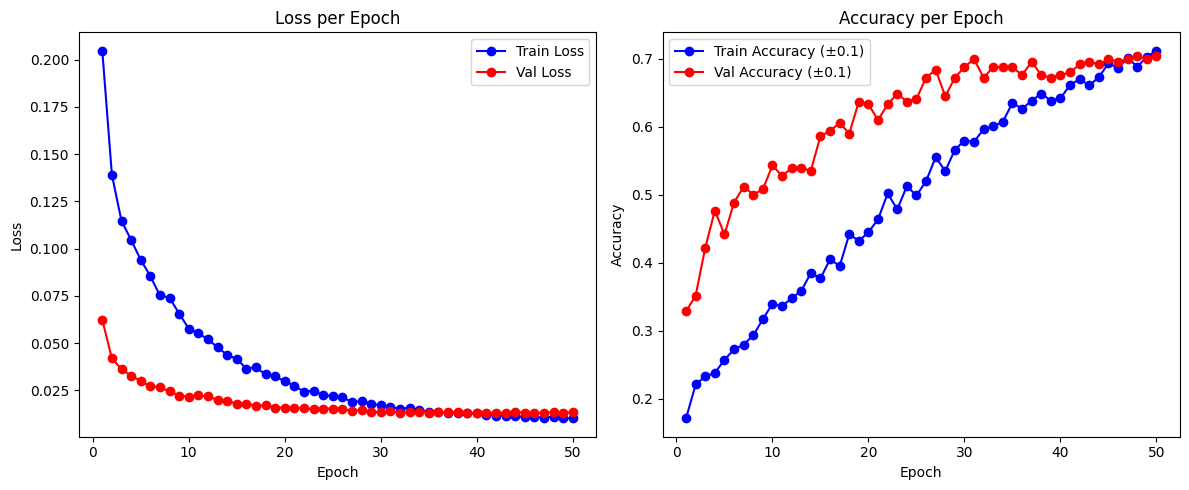

In [ ]:
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracie)

In [ ]:
class VisualSentimentModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout_rate=0.3):
        super(VisualSentimentModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, 1)

        self.dropout = nn.Dropout(dropout_rate)
        self.batch_norm1 = nn.BatchNorm1d(hidden_dim)
        self.batch_norm2 = nn.BatchNorm1d(hidden_dim // 2)

    def forward(self, x):
        x = self.fc1(x)
        x = self.batch_norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.batch_norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)
        return x

In [ ]:
def train_visual_model(train_loader, val_loader, input_dim, model_path='visual_model.pt', num_epochs=50, lr=1e-3):
    model = VisualSentimentModel(input_dim).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(1, num_epochs + 1):
        model.train()
        epoch_loss = 0.0
        all_preds, all_labels = [], []

        pbar = tqdm(train_loader, desc=f"[Epoch {epoch}] Training")
        for batch in pbar:
            inputs = batch["visual"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            all_preds.extend(outputs.squeeze().detach().cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            pbar.set_postfix({"loss": loss.item()})

        avg_train_loss = epoch_loss / len(train_loader)
        train_acc = accuracy_within_tolerance(all_preds, all_labels)
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_acc)

        # Validation
        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                inputs = batch["visual"].to(DEVICE)
                labels = batch["label"].to(DEVICE)

                outputs = model(inputs)
                loss = criterion(outputs.squeeze(), labels)
                val_loss += loss.item()

                all_preds.extend(outputs.squeeze().cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_acc = accuracy_within_tolerance(all_preds, all_labels)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        print(f"[Epoch {epoch}] Train Loss: {avg_train_loss:.4f}, Train Accuracy (±0.1): {train_acc:.4f}")
        print(f"[Epoch {epoch}] Val Loss: {avg_val_loss:.4f}, Val Accuracy (±0.1): {val_acc:.4f}")
        print(f"[Epoch {epoch}] Sample Predictions: {np.round(all_preds[:5], 4)}")
        print(f"[Epoch {epoch}] Sample Labels     : {np.round(all_labels[:5], 4)}")

    torch.save(model.state_dict(), model_path)
    return model, train_losses, val_losses, train_accuracies, val_accuracies


In [ ]:
model, train_losses, val_losses, train_accuracies, val_accuracies = train_visual_model(train_loader, val_loader, input_dim=VISUAL_FEATURE_SIZE)


[Epoch 1] Training: 100%|██████████| 74/74 [00:00<00:00, 125.24it/s, loss=0.0584]


[Epoch 1] Train Loss: 0.0931, Train Accuracy (±0.1): 0.2838
[Epoch 1] Val Loss: 0.0215, Val Accuracy (±0.1): 0.5625
[Epoch 1] Sample Predictions: [0.0447 0.1835 0.1676 0.1519 0.1538]
[Epoch 1] Sample Labels     : [0.0741 0.2917 0.2659 0.1111 0.119 ]



[Epoch 2] Training: 100%|██████████| 74/74 [00:00<00:00, 111.25it/s, loss=0.03]


[Epoch 2] Train Loss: 0.0481, Train Accuracy (±0.1): 0.3615
[Epoch 2] Val Loss: 0.0220, Val Accuracy (±0.1): 0.4844
[Epoch 2] Sample Predictions: [0.1641 0.2777 0.2697 0.1968 0.2027]
[Epoch 2] Sample Labels     : [0.0741 0.2917 0.2659 0.1111 0.119 ]



[Epoch 3] Training: 100%|██████████| 74/74 [00:00<00:00, 119.53it/s, loss=0.0221]


...

[Epoch 48] Train Loss: 0.0198, Train Accuracy (±0.1): 0.5241
[Epoch 48] Val Loss: 0.0192, Val Accuracy (±0.1): 0.5352
[Epoch 48] Sample Predictions: [0.1854 0.1608 0.1631 0.2078 0.2117]
[Epoch 48] Sample Labels     : [0.0741 0.2917 0.2659 0.1111 0.119 ]



[Epoch 49] Training: 100%|██████████| 74/74 [00:00<00:00, 143.50it/s, loss=0.0195]


[Epoch 49] Train Loss: 0.0197, Train Accuracy (±0.1): 0.5266
[Epoch 49] Val Loss: 0.0192, Val Accuracy (±0.1): 0.5117
[Epoch 49] Sample Predictions: [0.1783 0.1623 0.1666 0.2226 0.2269]
[Epoch 49] Sample Labels     : [0.0741 0.2917 0.2659 0.1111 0.119 ]



[Epoch 50] Training: 100%|██████████| 74/74 [00:00<00:00, 111.80it/s, loss=0.0298]


[Epoch 50] Train Loss: 0.0197, Train Accuracy (±0.1): 0.5224
[Epoch 50] Val Loss: 0.0192, Val Accuracy (±0.1): 0.5352
[Epoch 50] Sample Predictions: [0.1493 0.1645 0.1615 0.1997 0.2005]
[Epoch 50] Sample Labels     : [0.0741 0.2917 0.2659 0.1111 0.119 ]


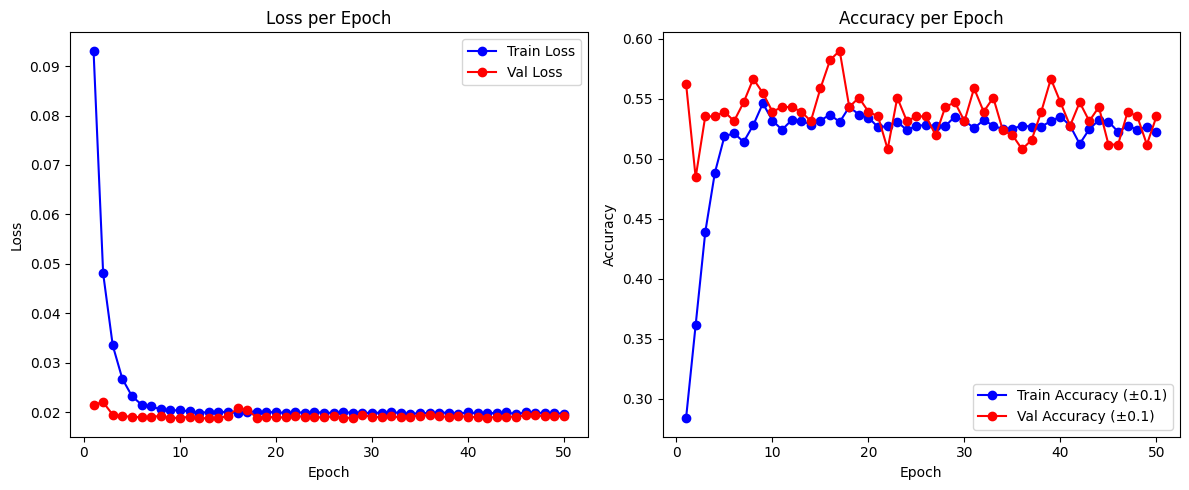

In [ ]:
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies)

In [ ]:
audio_model = AudioSentimentModel(input_dim=AUDIO_FEATURE_SIZE, hidden_dim = 256).to(DEVICE)
visual_model = VisualSentimentModel(input_dim=VISUAL_FEATURE_SIZE, hidden_dim = 256).to(DEVICE)
text_model = TextSentimentModel(input_dim=TEXT_EMBEDDING_DIM, hidden_dim = 256).to(DEVICE)

In [ ]:
class TransformerAudioEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, num_heads=4, dropout_rate=0.3):
        super(TransformerAudioEncoder, self).__init__()
        self.input_projection = nn.Linear(input_dim, hidden_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=num_heads, dim_feedforward=hidden_dim * 4,
            dropout=dropout_rate, activation="relu", batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_projection = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout_rate)

    def get_encoded_features(self, x):
        x = self.input_projection(x)

        if len(x.shape) == 2:
            x = x.unsqueeze(1)

        x = self.transformer_encoder(x)

        encoded = x[:, 0, :]
        return encoded

    def forward(self, x):
        encoded = self.get_encoded_features(x)
        sentiment = self.output_projection(encoded)
        return encoded, sentiment

In [ ]:
class TransformerVisualEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, num_heads=4, dropout_rate=0.3):
        super(TransformerVisualEncoder, self).__init__()
        self.input_projection = nn.Linear(input_dim, hidden_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=num_heads, dim_feedforward=hidden_dim * 4,
            dropout=dropout_rate, activation="relu", batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_projection = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout_rate)

    def get_encoded_features(self, x):
        x = self.input_projection(x)
        if len(x.shape) == 2:
            x = x.unsqueeze(1)
        x = self.transformer_encoder(x)
        encoded = x[:, 0, :]
        return encoded

    def forward(self, x):
        encoded = self.get_encoded_features(x)
        sentiment = self.output_projection(encoded)
        return encoded, sentiment


In [ ]:
class TransformerTextEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, num_layers=4, num_heads=8, dropout_rate=0.3):
        super(TransformerTextEncoder, self).__init__()
        self.input_projection = nn.Linear(input_dim, hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=num_heads, dim_feedforward=hidden_dim * 4,
            dropout=dropout_rate, activation="relu", batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_projection = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout_rate)

    def get_encoded_features(self, x):
        # print(f"TransformerTextEncoder input shape: {x.shape}")
        x = self.input_projection(x)
        if len(x.shape) == 2:
            x = x.unsqueeze(1)
        # print(f"TransformerTextEncoder after projection: {x.shape}")
        x = self.transformer_encoder(x)
        encoded = x[:, 0, :]
        # print(f"TransformerTextEncoder output shape: {encoded.shape}")
        return encoded

    def forward(self, x):
        encoded = self.get_encoded_features(x)
        sentiment = self.output_projection(encoded)
        return encoded, sentiment

In [ ]:
class EarlyFusionModel(nn.Module):
    def __init__(self, text_dim,  visual_dim, hidden_dim=256, dropout_rate=0.3):
        super(EarlyFusionModel, self).__init__()
        total_dim = text_dim +  visual_dim

        self.fusion_layers = nn.Sequential(
            nn.Linear(total_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, text_features,  visual_features):
        concat_features = torch.cat([text_features,  visual_features], dim=1)
        sentiment = self.fusion_layers(concat_features)
        return sentiment


In [ ]:
class LateFusionModel(nn.Module):
    def __init__(self,text_model,  visual_model, fusion_weights=None):
        super(LateFusionModel, self).__init__()
        self.text_model = text_model
        # self.audio_model = audio_model
        self.visual_model = visual_model

        # for model in [self.text_model, self.audio_model, self.visual_model]:
        #     for param in model.parameters():
        #         param.requires_grad = False

        if fusion_weights is None:
            self.fusion_weights = nn.Parameter(torch.ones(3) / 3)
        else:
            self.fusion_weights = torch.tensor(fusion_weights)

    def forward(self, features):
        text_features = features["language"]
        # audio_features = features["acoustic"]
        visual_features = features["visual"]

        # audio_pred = self.audio_model(audio_features)
        visual_pred = self.visual_model(visual_features)
        text_pred = self.text_model(text_features)

        weights = F.softmax(self.fusion_weights, dim=0)

        combined_pred = weights[0] * text_pred +  weights[2] * visual_pred
        return combined_pred

In [ ]:
class TransformerFusionModel(nn.Module):
    def __init__(self, text_dim,  visual_dim, hidden_dim=256, num_heads=8, num_layers=4, dropout_rate=0.3):
        super(TransformerFusionModel, self).__init__()

        self.text_encoder = TransformerTextEncoder(
            text_dim, hidden_dim, num_layers, num_heads, dropout_rate
        )

        # self.audio_encoder = TransformerAudioEncoder(
        #     audio_dim, hidden_dim // 2, num_layers // 2, num_heads // 2, dropout_rate
        # )

        self.visual_encoder = TransformerVisualEncoder(
            visual_dim, hidden_dim // 2, num_layers // 2, num_heads // 2, dropout_rate
        )

        # Multimodal cross-attention fusion
        self.fusion_module = MultimodalCrossAttention(
            hidden_dim, hidden_dim // 2, hidden_dim // 2, hidden_dim, num_heads, dropout_rate
        )
        self.output_proj = nn.Linear(hidden_dim, 1)

    def forward(self, features):
        text_features = features["language"]
        # audio_features = features["acoustic"]
        visual_features = features["visual"]

        # print(f"text_features shape: {text_features.shape}")
        # print(f"audio_features shape: {audio_features.shape}")
        # print(f"visual_features shape: {visual_features.shape}")

        # Encode each modality using respective transformer encoders
        text_encoded = self.text_encoder.get_encoded_features(text_features)
        # audio_encoded = self.audio_encoder.get_encoded_features(audio_features)
        visual_encoded = self.visual_encoder.get_encoded_features(visual_features)

        fused_features, sentiment = self.fusion_module(
            text_encoded, visual_encoded
        )

        return sentiment

In [ ]:
input_dims = {
    "language": TEXT_EMBEDDING_DIM,
    # "acoustic": AUDIO_FEATURE_SIZE,
    "visual": VISUAL_FEATURE_SIZE
}
models = {
    "LateFusion": LateFusionModel(text_model,  visual_model),
    "TransformerFusion": TransformerFusionModel(
        text_dim=input_dims["language"],
        # audio_dim=input_dims["acoustic"],
        visual_dim=input_dims["visual"],
        hidden_dim=256,
        num_layers= 4,
        num_heads= 8,
        dropout_rate=0.3
    )
}

In [ ]:
logger = logging.getLogger(__name__)

def calc_mae(preds, labels):
    return mean_absolute_error(labels, preds)

def calc_correlation(preds, labels):
    if np.std(preds) == 0 or np.std(labels) == 0:
        return 0.0

    return np.corrcoef(preds, labels)[0, 1]

def calc_binary_accuracy(preds, labels, threshold=0):
    binary_preds = (preds > threshold).astype(int)
    binary_labels = (labels > threshold).astype(int)

    return accuracy_score(binary_labels, binary_preds)

def calc_f1(preds, labels, threshold=0):
    binary_preds = (preds > threshold).astype(int)
    binary_labels = (labels > threshold).astype(int)

    return f1_score(binary_labels, binary_preds, zero_division=0)

def calc_accuracy(y_true, y_pred):
    print(f"accuracy", accuracy_score(y_true, y_pred))
    return accuracy_score(y_true, y_pred)

def calc_multiclass_metrics(preds, labels):
    # Round to nearest integer and clip to [-3, 3] range
    rounded_preds = np.round(preds).clip(-3, 3)
    rounded_labels = np.round(labels).clip(-3, 3)

    # Convert to 7 classes (0-6 for -3 to +3)
    preds_classes = (rounded_preds + 3).astype(int)
    labels_classes = (rounded_labels + 3).astype(int)

    # Calculate metrics
    acc = accuracy_score(labels_classes, preds_classes)
    f1 = f1_score(labels_classes, preds_classes, average="weighted", zero_division=0)

    return {
        "multiclass_acc": acc,
        "multiclass_f1": f1
    }

def get_predictions(model, dataloader, device):

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            # Get batch data
            if isinstance(batch, dict):
                # Multimodal data
                inputs = {k: v.to(device) for k, v in batch.items() if k != "label"}
                labels = batch["label"].to(device)
            else:
                # Unimodal data
                inputs, labels = batch
                inputs = inputs.to(device)
                labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)
            outputs = torch.nan_to_num(outputs, nan=0.0)

            # Collect predictions and labels
            preds = outputs.squeeze().cpu().numpy()
            labels = labels.cpu().numpy()

            all_preds.append(preds)
            all_labels.append(labels)

    # Concatenate batch results
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    return all_preds, all_labels

def evaluate_mosei(model, dataloader, device):
    all_preds, all_labels = get_predictions(model, dataloader, device)

    # Calculate metrics
    mae = calc_mae(all_preds, all_labels)
    corr = calc_correlation(all_preds, all_labels)
    # acc1 = calc_accuracy(all_labels, all_preds)
    acc = calc_binary_accuracy(all_preds, all_labels)
    f1 = calc_f1(all_preds, all_labels)

    # Multi-class metrics
    multiclass_metrics = calc_multiclass_metrics(all_preds, all_labels)

    # Combine all metrics
    metrics = {
        "mae": mae,
        "corr": corr,
        "binary_acc": acc,
        # "accuracy": acc1,
        "binary_f1": f1,
        **multiclass_metrics
    }

    return metrics

def log_metrics(metrics, split, epoch=None):
    epoch_str = f"Epoch {epoch} - " if epoch is not None else ""
    logger.info(f"{epoch_str}{split.capitalize()} metrics:")
    logger.info(f"  MAE: {metrics['mae']:.4f}")
    logger.info(f"  Correlation: {metrics['corr']:.4f}")
    logger.info(f"  Binary Accuracy: {metrics['binary_acc']:.4f}")
    logger.info(f"  Binary F1: {metrics['binary_f1']:.4f}")
    logger.info(f"  7-class Accuracy: {metrics['multiclass_acc']:.4f}")
    logger.info(f"  7-class F1: {metrics['multiclass_f1']:.4f}")


In [ ]:
class Trainer:
    def __init__(
        self,model,train_loader, val_loader, test_loader=None,lr=1e-4, weight_decay=1e-5,device=None, model_dir=None,log_dir=None, experiment_name=None):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader

        # Set device
        self.device = device if device is not None else DEVICE
        self.model = self.model.to(self.device)

        # Setup optimizer and loss function
        self.optimizer = optim.Adam(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )
        self.criterion = nn.MSELoss()

        # Setup paths for saving models and logs
        self.model_dir = Path(model_dir) if model_dir is not None else Path("/content/models")
        self.model_dir.mkdir(exist_ok=True, parents=True)

        # self.log_dir = Path(log_dir) if log_dir is not None else Path(LOGS_DIR)
        # self.log_dir.mkdir(exist_ok=True, parents=True)

        # Set experiment name
        if experiment_name is None:
            self.experiment_name = f"{model.__class__.__name__}_{time.strftime('%Y%m%d_%H%M%S')}"
        else:
            self.experiment_name = experiment_name

        # Setup logging
        # self.log_file = self.log_dir / f"{self.experiment_name}.log"
        # setup_logging(self.log_file)

        # Track best validation performance
        self.best_val_loss = float("inf")
        self.best_epoch = 0
        self.patience_counter = 0

    def train_epoch(self, epoch):
        """
        Train the model for a single epoch.
        """
        self.model.train()
        epoch_loss = 0.0

        # Use tqdm for progress bar
        pbar = tqdm(total=len(self.train_loader), desc=f"Epoch {epoch}")

        for batch_idx, batch in enumerate(self.train_loader):
            # Get batch data
            if isinstance(batch, dict):
                # Multimodal data
                inputs = {k: v.to(self.device) for k, v in batch.items() if k != "label"}
                labels = batch["label"].to(self.device)
            else:
                # Unimodal data
                inputs, labels = batch
                inputs = inputs.to(self.device)
                labels = labels.to(self.device)

            # Reset gradients
            self.optimizer.zero_grad()

            # Forward pass
            outputs = self.model(inputs)
            outputs = torch.nan_to_num(outputs, nan=0.0)  # Xử lý NaN trong outputs

            # Calculate loss
            loss = self.criterion(outputs.squeeze(), labels)
            if torch.isnan(loss):
                logger.warning(f"NaN loss detected in epoch {epoch}, batch {batch_idx}")
                continue

            # Backward pass and optimize
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)  # Gradient clipping
            self.optimizer.step()

            # Update statistics
            epoch_loss += loss.item()

            # Update progress bar
            pbar.update(1)
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        pbar.close()

        # Calculate average loss
        avg_loss = epoch_loss / len(self.train_loader)

        return avg_loss

    def validate(self, epoch):

        self.model.eval()
        val_loss = 0.0

        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in self.val_loader:
                # Get batch data
                if isinstance(batch, dict):
                    # Multimodal data
                    inputs = {k: v.to(self.device) for k, v in batch.items() if k != "label"}
                    labels = batch["label"].to(self.device)
                else:
                    # Unimodal data
                    inputs, labels = batch
                    inputs = inputs.to(self.device)
                    labels = labels.to(self.device)

                # Forward pass
                outputs = self.model(inputs)
                outputs = torch.nan_to_num(outputs, nan=0.0)  # Xử lý NaN trong outputs

                # Calculate loss
                loss = self.criterion(outputs.squeeze(), labels)
                if torch.isnan(loss):
                    logger.warning(f"NaN loss detected in validation, epoch {epoch}")
                    continue

                # Update statistics
                val_loss += loss.item()

                # Collect predictions and labels
                preds = outputs.squeeze().cpu().numpy()
                labels = labels.cpu().numpy()

                all_preds.append(preds)
                all_labels.append(labels)

        # print("Sample predictions:", all_preds[:10])
        # print("Sample labels     :", all_labels[:10])

        # Calculate average loss
        avg_loss = val_loss / len(self.val_loader)

        # Concatenate batch results
        all_preds = np.concatenate(all_preds)
        all_labels = np.concatenate(all_labels)

        # Xử lý NaN trước khi tính metrics
        if np.any(np.isnan(all_preds)) or np.any(np.isnan(all_labels)):
            logger.warning("NaN detected in predictions or labels, applying nan_to_num")
            all_preds = np.nan_to_num(all_preds, nan=0.0)
            all_labels = np.nan_to_num(all_labels, nan=0.0)

        # Evaluate using metrics
        metrics = evaluate_mosei(self.model, self.val_loader, self.device)

        return avg_loss, metrics

    def test(self):
        """
        Evaluate the best model on the test set.
        """
        if self.test_loader is None:
            logger.warning("Test loader not provided. Skipping test evaluation.")
            return None

        logger.info("Evaluating model on test set...")
        metrics = evaluate_mosei(self.model, self.test_loader, self.device)
        log_metrics(metrics, "test")

        return metrics

    def save_checkpoint(self, epoch, val_loss, is_best=False):
        checkpoint = {
            "epoch": epoch,
            "model_state_dict": self.model.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict(),
            "val_loss": val_loss,
        }

        # Save regular checkpoint
        checkpoint_path = self.model_dir / f"{self.experiment_name}_epoch_{epoch}.pt"
        torch.save(checkpoint, checkpoint_path)
        logger.info(f"Saved checkpoint to {checkpoint_path}")

        # Save best model
        if is_best:
            best_path = self.model_dir / f"{self.experiment_name}_best.pt"
            torch.save(checkpoint, best_path)
            logger.info(f"Saved best model to {best_path}")

    def load_checkpoint(self, checkpoint_path=None):
        if checkpoint_path is None:
            checkpoint_path = self.model_dir / f"{self.experiment_name}_best.pt"

        if not Path(checkpoint_path).exists():
            logger.warning(f"Checkpoint {checkpoint_path} not found. Skipping.")
            return

        logger.info(f"Loading checkpoint from {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=self.device)

        # Load model and optimizer states
        self.model.load_state_dict(checkpoint["model_state_dict"])
        self.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

        # Set best validation loss
        if "val_loss" in checkpoint:
            self.best_val_loss = checkpoint["val_loss"]
            logger.info(f"Best validation loss: {self.best_val_loss:.4f}")

    def train(self, start_epoch=1, num_epochs=50, patience=20, eval_every=1):
        logger.info(f"Starting training for {num_epochs} epochs")
        logger.info(f"Model: {self.model.__class__.__name__}")
        logger.info(f"Device: {self.device}")
        logger.info(f"Train samples: {len(self.train_loader.dataset)}")
        logger.info(f"Validation samples: {len(self.val_loader.dataset)}")
        if self.test_loader is not None:
            logger.info(f"Test samples: {len(self.test_loader.dataset)}")

        best_val_metrics = None
        best_model = None
        self.best_val_loss = float('inf')
        self.best_epoch = 0
        self.patience_counter = 0

        train_losses = []
        val_losses = []
        train_metrics_list = []
        val_metrics_list = []

        for epoch in range(start_epoch, num_epochs + 1):
            # Train for one epoch
            train_loss = self.train_epoch(epoch)
            train_losses.append(train_loss)
            logger.info(f"Epoch {epoch} - Train loss: {train_loss:.4f}")

            if epoch % eval_every == 0:
                val_loss, val_metrics = self.validate(epoch)
                val_losses.append(val_loss)
                val_metrics_list.append(val_metrics)
                logger.info(f"Epoch {epoch} - Validation loss: {val_loss:.4f}")
                log_metrics(val_metrics, "val", epoch)

                train_metrics = evaluate_mosei(self.model, self.train_loader, self.device)
                train_metrics_list.append(train_metrics)
                log_metrics(train_metrics, "train", epoch)

                if val_loss < self.best_val_loss:
                    self.best_val_loss = val_loss
                    self.best_epoch = epoch
                    best_model = self.model
                    best_val_metrics = val_metrics
                    self.patience_counter = 0

                    self.save_checkpoint(epoch, val_loss, is_best=True)
                    logger.info(f"New best model at epoch {epoch}")
                else:
                    self.patience_counter += 1
                    logger.info(f"No improvement for {self.patience_counter} epochs")

                    if self.patience_counter >= patience:
                        logger.info(f"Early stopping at epoch {epoch}")
                        break

            if epoch % 5 == 0 or epoch == num_epochs:
                self.save_checkpoint(epoch, val_loss if epoch % eval_every == 0 else float("inf"))

        logger.info(f"Training completed. Best model at epoch {self.best_epoch}")

        return best_model, train_losses, val_losses, train_metrics_list, val_metrics_list

In [ ]:
def plot_training_curves(train_losses, val_losses, metrics, save_path, model_name):
    plt.figure(figsize=(10, 8))
    plt.subplot(2, 1, 1)
    plt.plot(train_losses, label="Training Loss", color="blue")
    plt.plot(val_losses, label="Validate Loss", color="red")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training loss and validate loss - {model_name}")
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 1, 2)
    for metric_name in ["mae", "corr", "binary_acc", "binary_f1"]:
        plt.plot([m[metric_name] for m in metrics], label=metric_name.capitalize())
    plt.xlabel("Epoch")
    plt.ylabel("Index value")
    plt.title(f"Index validation - {model_name}")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved training curve graph for {model_name} in {save_path}")
    plt.show()
    plt.close()

# Hàm trực quan hóa so sánh mô hình
def plot_results_summary(results, save_path):
    metrics = ["mae", "corr", "binary_acc",  "binary_f1"]
    model_names = list(results.keys())
    metric_values = {metric: [results[model][metric] for model in model_names] for metric in metrics}

    plt.figure(figsize=(12, 6))
    x = np.arange(len(model_names))
    width = 0.2

    for i, metric in enumerate(metrics):
        plt.bar(x + i * width, metric_values[metric], width, label=metric.capitalize())

    plt.xlabel("Model")
    plt.ylabel("Index value")
    plt.title("Compare model")
    plt.xticks(x + width * 1.5, model_names)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Model comparison chart saved to {save_path}")
    plt.show()
    plt.close()


In [ ]:
results = {}
plot_dir = Path("content/plots")
plot_dir.mkdir(exist_ok=True, parents=True)

for model_name, model in models.items():
    print(f"Training model {model_name}...")
    trainer = Trainer(model, train_loader, val_loader, test_loader)
    best_model, train_losses, val_losses, train_metrics_list, val_metrics_list = trainer.train(num_epochs=20, patience=20)
    print(NUM_EPOCHS)
    # Lưu kết quả
    best_metrics = val_metrics_list[-1]
    results[model_name] = best_metrics

Training model LateFusion...




Epoch 1:   0%|          | 0/74 [00:00<?, ?it/s]

Epoch 1:   1%|▏         | 1/74 [00:00<00:00, 84.99it/s, loss=0.0128]

Epoch 1:   3%|▎         | 2/74 [00:00<00:00, 89.59it/s, loss=0.0102]

Epoch 1:   4%|▍         | 3/74 [00:00<00:00, 93.73it/s, loss=0.0151]

Epoch 1:   5%|▌         | 4/74 [00:00<00:00, 96.45it/s, loss=0.0098]

Epoch 1:   7%|▋         | 5/74 [00:00<00:00, 98.11it/s, loss=0.0138]

Epoch 1:   8%|▊         | 6/74 [00:00<00:00, 99.92it/s, loss=0.0117]

Epoch 1:   9%|▉         | 7/74 [00:00<00:00, 100.85it/s, loss=0.0125]

Epoch 1:  11%|█         | 8/74 [00:00<00:00, 101.37it/s, loss=0.0150]

Epoch 1:  12%|█▏        | 9/74 [00:00<00:00, 101.73it/s, loss=0.0144]

Epoch 1:  14%|█▎        | 10/74 [00:00<00:00, 102.03it/s, loss=0.0077]

Epoch 1:  15%|█▍        | 11/74 [00:00<00:00, 102.41it/s, loss=0.0077]

Epoch 1:  15%|█▍        | 11/74 [00:00<00:00, 102.41it/s, loss=0.0195]

Epoch 1:  16%|█▌        | 12/74 [00:00<00:00, 102.41it/s, loss=0.0145]

Epoch 1:  18%|█▊        | 13

50
Training model TransformerFusion...




Epoch 1:   0%|          | 0/74 [00:00<?, ?it/s]

RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x384 and 512x512)

In [ ]:
plot_training_curves(
      train_losses, val_losses, val_metrics_list,
      save_path=str(plot_dir / f"training_curves_{model_name.lower()}_av.png"),
      model_name=model_name
  )

print(plot_training_curves)

In [ ]:
print("Creating model comparison chart...")
plot_results_summary(results, str(plot_dir / "model_comparison_av.png"))
print(plot_results_summary)
# Đánh giá mô hình tốt nhất trên tập kiểm tra
best_model_name = min(results, key=lambda x: results[x]["mae"])
print(f"Evaluating the best model ({best_model_name}) in val set...")
trainer = Trainer(models[best_model_name], train_loader, val_loader, test_loader)
test_loss, test_metrics = trainer.validate(0)
print(f"Test results for {best_model_name}: Loss: {test_loss:.4f}, MAE: {test_metrics['mae']:.4f}, Corr: {test_metrics['corr']:.4f}, Binary Acc: {test_metrics['binary_acc']:.4f}, Binary F1: {test_metrics['binary_f1']:.4f}")


In [ ]:
table = PrettyTable()
table.field_names = ["Model", "MAE", "Corr", "Binary Acc","Accuracy" "Binary F1"]
for model_name, metrics in results.items():
    table.add_row([model_name] + [metrics[metric] for metric in ["mae", "corr", "binary_acc", "binary_f1"]])
print(table)